# Globular Cluster Stream

This example demonstrates how tambora can be used with [galpy](https://docs.galpy.org/en/stable/) to simulate the formation of a globular cluster tidal stream in the Milky Way.

## Setting up the simulation

In [11]:
from tambora.simulation import Sim

stream = Sim()

For the Milky Way, let's use the NFW component of galpy's [MWPotential2014](https://docs.galpy.org/en/latest/tutorials/potentials/milky_way_potentials.html#MWPotential2014) potential and add it to our simulation.

In [12]:
from galpy.potential import MWPotential2014
import astropy.units as u

# create MW potential
host = MWPotential2014[2]
host.turn_physical_on(ro=8*u.kpc, vo=220*u.km/u.s)

# add the potential to the simulation
stream.add_external_pot(host)

Next, we construct the progenitor by sampling **10,000** positions, velocities, and masses from a  $4 \times 10^4 \text{M}_{\odot}$ King sphere using tambora's initial condition routines with galpy under the hood. The progenitor's location is chosen to land it at the present location of GD-1 after 5 Gyr.

In [14]:
t_end = -5. * u.Gyr

from tambora.tools import galpy_orbit_to_tambora
import numpy as np

sat_mass = 4e4 * u.Msun # progenitor mass

from galpy.orbit import Orbit
ic_orb = Orbit.from_name('GD-1')
ic_orb.turn_physical_on()

ts_back = np.linspace(0, t_end, 100)
ic_orb.integrate(ts_back, host)
rtidal = host.rtide(R=ic_orb.R(t_end), z=ic_orb.z(t_end), M=sat_mass, quantity=True).to(u.kpc)

from tambora.tools import mkKing_galpy
pos, vel, mass = mkKing_galpy(m=sat_mass.value, n = 5_000, 
                              center_pos = [ic_orb.x(t_end).value, ic_orb.y(t_end).value, ic_orb.z(t_end).value],
                              center_vel = [ic_orb.vx(t_end).value, ic_orb.vy(t_end).value, ic_orb.vz(t_end).value],
                               W0=2, rt=rtidal.value)

In [15]:
print(f'Each particle has mass {np.mean(mass)} +/- {np.std(mass)} Msun')

Each particle has mass 8.0 +/- 0.0 Msun


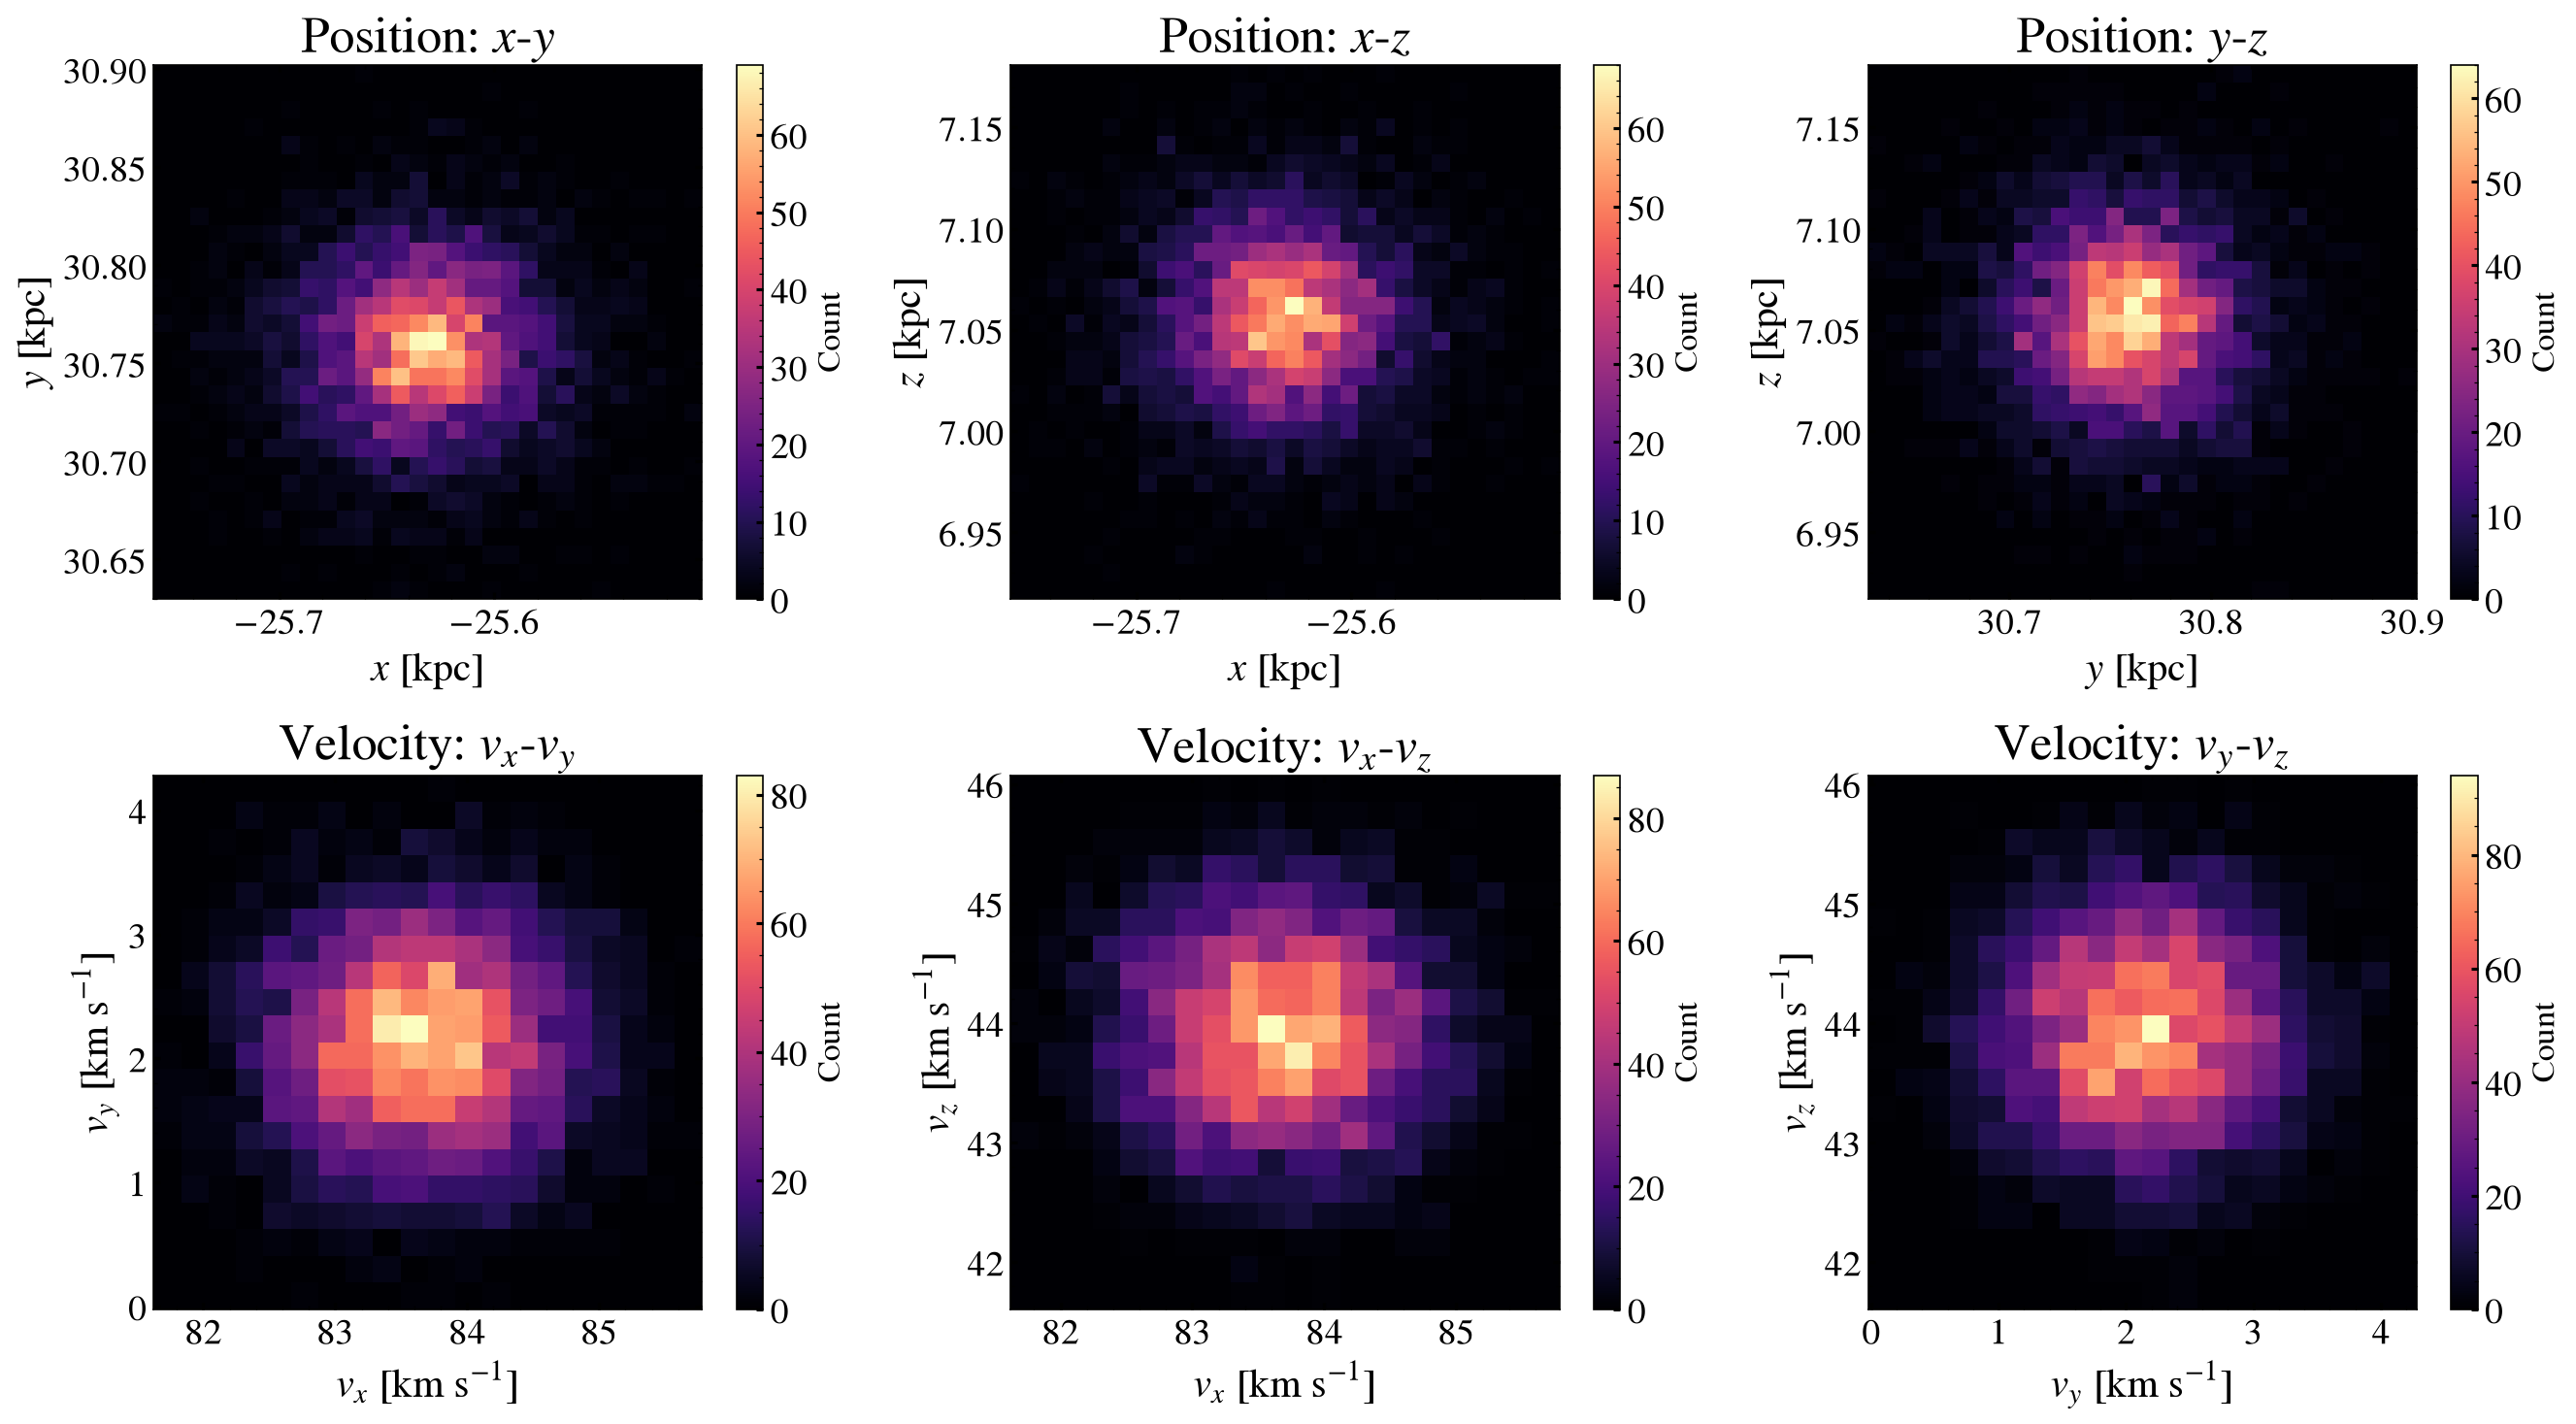

In [16]:
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=150)

# --- Top row: position projections ---
h_xy = axes[0, 0].hist2d(pos[:, 0], pos[:, 1], bins=30, cmap='magma')
axes[0, 0].set_xlabel(r'$x$ [kpc]', fontsize=20)
axes[0, 0].set_ylabel(r'$y$ [kpc]', fontsize=20)
axes[0, 0].set_title('Position: $x$-$y$', fontsize=25)
fig.colorbar(h_xy[3], ax=axes[0, 0], label='Count')

h_xz = axes[0, 1].hist2d(pos[:, 0], pos[:, 2], bins=30, cmap='magma')
axes[0, 1].set_xlabel(r'$x$ [kpc]', fontsize=20)
axes[0, 1].set_ylabel(r'$z$ [kpc]', fontsize=20)
axes[0, 1].set_title('Position: $x$-$z$', fontsize=25)
fig.colorbar(h_xz[3], ax=axes[0, 1], label='Count')

h_yz = axes[0, 2].hist2d(pos[:, 1], pos[:, 2], bins=30, cmap='magma')
axes[0, 2].set_xlabel(r'$y$ [kpc]', fontsize=20)
axes[0, 2].set_ylabel(r'$z$ [kpc]', fontsize=20)
axes[0, 2].set_title('Position: $y$-$z$', fontsize=25)
fig.colorbar(h_yz[3], ax=axes[0, 2], label='Count')

# --- Bottom row: velocity projections ---
h_vxvy = axes[1, 0].hist2d(vel[:, 0], vel[:, 1], bins=20, cmap='magma')
axes[1, 0].set_xlabel(r'$v_x$ [km s$^{-1}$]', fontsize=20)
axes[1, 0].set_ylabel(r'$v_y$ [km s$^{-1}$]', fontsize=20)
axes[1, 0].set_title('Velocity: $v_x$-$v_y$', fontsize=25)
fig.colorbar(h_vxvy[3], ax=axes[1, 0], label='Count')

h_vxvz = axes[1, 1].hist2d(vel[:, 0], vel[:, 2], bins=20, cmap='magma')
axes[1, 1].set_xlabel(r'$v_x$ [km s$^{-1}$]', fontsize=20)
axes[1, 1].set_ylabel(r'$v_z$ [km s$^{-1}$]', fontsize=20)
axes[1, 1].set_title('Velocity: $v_x$-$v_z$', fontsize=25)
fig.colorbar(h_vxvz[3], ax=axes[1, 1], label='Count')

h_vyvz = axes[1, 2].hist2d(vel[:, 1], vel[:, 2], bins=20, cmap='magma')
axes[1, 2].set_xlabel(r'$v_y$ [km s$^{-1}$]', fontsize=20)
axes[1, 2].set_ylabel(r'$v_z$ [km s$^{-1}$]', fontsize=20)
axes[1, 2].set_title('Velocity: $v_y$-$v_z$', fontsize=25)
fig.colorbar(h_vyvz[3], ax=axes[1, 2], label='Count')

fig.tight_layout()
plt.show()

And we add these particles to the simulation:

In [17]:
stream.add_particles('stars', pos=pos, vel=vel, mass=mass)
stream.components

(Component('stars', 5000 particles, 4.00e+04 Msun),)

We can compare the sampled density profile to the analytic profile:

/geir_data/scr/gabrielspace/tambora/.venv/lib/python3.12/site-packages/galpy/potential/SphericalPotential.py:50: RuntimeWarning: divide by zero encountered in divide
  return (self._r2deriv(r, t=t) - 2.0 * self._rforce(r, t=t) / r) / 4.0 / numpy.pi



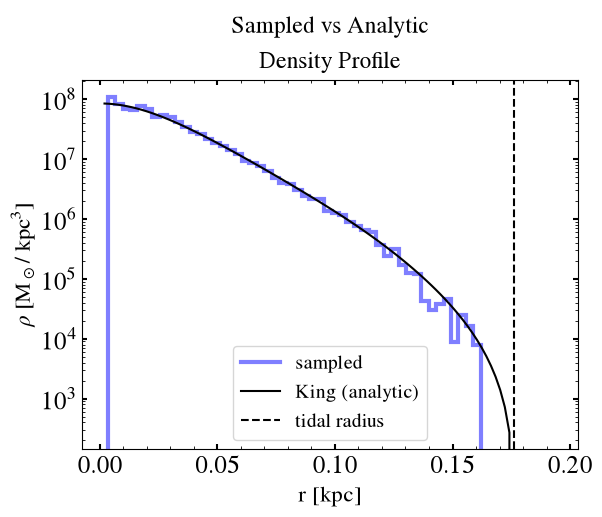

In [18]:
from galpy.potential import KingPotential

kingpot = KingPotential(M=sat_mass, W0=2, rt=rtidal)

# 3D distance of each star from the cluster center
cen = np.median(stream.stars.pos(0), axis=0)
d   = np.linalg.norm(stream.stars.pos(0) - cen, axis=1)

# counts -> volume density via shell volumes
counts, bins = np.histogram(d, bins=50)
r_mid = 0.5 * (bins[:-1] + bins[1:])
shell_vol = 4 * np.pi * r_mid**2 * np.diff(bins)
rho = counts * np.mean(mass) / shell_vol           # M⊙ / kpc^3

rlist = np.linspace(0, 1.1 * rtidal.value, 100) * u.kpc
plt.stairs(rho, bins, color='blue', linewidth=3, label='sampled', alpha=0.5)
plt.plot(rlist, kingpot.dens(rlist, z=0, quantity=True).to(u.Msun / u.kpc**3),
         label='King (analytic)', c='k')
plt.axvline(rtidal.value, ls='--', c='k', label='tidal radius')
plt.xlabel('r [kpc]'); plt.ylabel(r'$\rho$ [M$_\odot$/ kpc$^3$]')
plt.yscale('log'); plt.legend()
plt.title('Sampled vs Analytic\nDensity Profile')
plt.show()

With the particles added, we can do all sorts of fun things like visualize the self-gravity and external forces/accelerations using the helpful accessor methods of {class}`~tambora.simulation.Sim`.

In [19]:
# --- Positions ---------------------------------------- #
xpos = stream.x(0)
ypos = stream.y(0)

# --- Self-Gravity Accelerations ----------------------- #
x_self_acc = stream.self_ax(0, method='falcON', eps=0.01)
y_self_acc = stream.self_ay(0, method='falcON', eps=0.01)

# --- External Field Accelerations --------------------- #
x_ext_acc = stream.external_ax(0)
y_ext_acc = stream.external_ay(0)

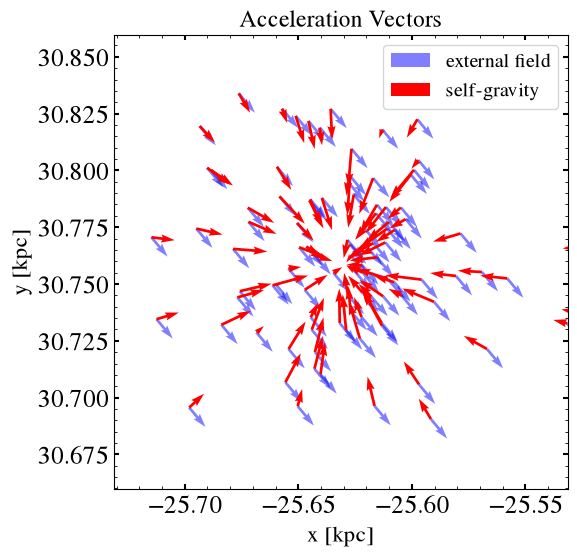

In [20]:
skip_every = 50
fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(stream.x(0)[::skip_every], stream.y(0)[::skip_every], 
          stream.external_ax(0)[::skip_every], stream.external_ay(0)[::skip_every], 
          alpha=0.5, color='b', label='external field')
ax.quiver(stream.x(0)[::skip_every], stream.y(0)[::skip_every], 
          stream.self_ax(0, method='falcON', eps=0.01)[::skip_every], 
          stream.self_ay(0, method='falcON', eps=0.01)[::skip_every], 
          alpha=1, color='r', label='self-gravity')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_title('Acceleration Vectors')
ax.set_aspect('equal')
plt.tight_layout()
plt.xlim(ic_orb.x(t_end).value - 0.1, ic_orb.x(t_end).value + 0.1)
plt.ylim(ic_orb.y(t_end).value - 0.1, ic_orb.y(t_end).value + 0.1)
plt.legend()

plt.show()

## Running the simulation

Let's add a hook to track which particles are bound/unbound at sub-snapshot time resolution. In this case, boundedness will be calculated every other (internal) step.

In [21]:
from tambora.dynamics.hooks import BoundednessHook, EveryNSteps

bh = BoundednessHook('stars', eps=0.0015, track=('com', 'com_vel'))
stream.add_hook(bh, EveryNSteps(2))

Next, the `run` method evolves the particles under the influence of self-gravity and the external potential for **5.0 Gyr**. I elect to compute self-gravity with `falcON` here.

Runs in **~7 minutes**

In [22]:
stream.run(t_end = 5.0, dt = 0.0005, dt_out=0.01, method='falcON', eps=0.0015)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [03:26<00:00, 48.38it/s, n_bound(stars)=1463, |dE/E0|=1.77e-06]


Anddd, **it's a stream!**

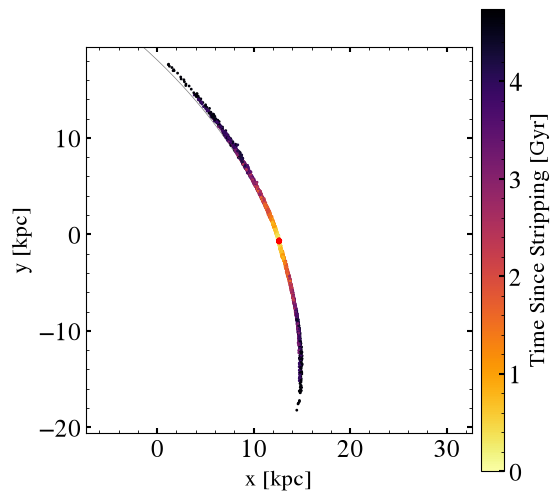

In [23]:
t_ind = -1
skip = 1

bnd = bh.mask_at(stream.times[t_ind])
com = np.array(bh.com)
com_t_ind = np.argmin(np.abs(stream.times[t_ind] - bh.t))
tstrip = stream.times[-1] - bh.release_time(stream.times[t_ind])[~bnd]

fig, ax = plt.subplots(figsize=(6,6))

ax.plot(com[com_t_ind-200:com_t_ind+200,0], com[com_t_ind-200:com_t_ind+200, 1], c='k', alpha=0.5, lw=0.5, zorder=0)
sct = ax.scatter(stream.x(t_ind)[~bnd][::skip], stream.y(t_ind)[~bnd][::skip], c=tstrip, cmap='inferno_r', alpha=1., s=1)
cb = fig.colorbar(sct, ax=ax, pad=0.02)

ax.scatter(stream.x(t_ind)[bnd][::skip], stream.y(t_ind)[bnd][::skip], s=2, alpha=1, c='r')

ax.set_xlim(com[com_t_ind][0] - 20, com[com_t_ind][0] + 20)
ax.set_ylim(com[com_t_ind][1] - 20, com[com_t_ind][1] + 20)
cb.set_label(r'Time Since Stripping [Gyr]')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_aspect('equal')
plt.show()

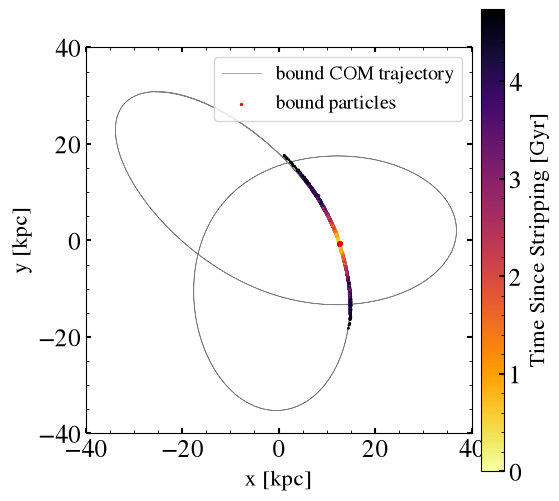

In [24]:
t_ind = -1
skip = 1

bnd = bh.mask_at(stream.times[t_ind])
com = np.array(bh.com)
com_t_ind = np.argmin(np.abs(stream.times[t_ind] - bh.t))
tstrip = stream.times[-1] - bh.release_time(stream.times[t_ind])[~bnd]

fig, ax = plt.subplots(figsize=(6,6))

ax.plot(com[:,0], com[:, 1], c='k', alpha=0.5, lw=0.5, zorder=0, label='bound COM trajectory')
sct = ax.scatter(stream.x(t_ind)[~bnd][::skip], stream.y(t_ind)[~bnd][::skip], c=tstrip, cmap='inferno_r', alpha=1., s=1)
cb = fig.colorbar(sct, ax=ax, pad=0.02)

ax.scatter(stream.x(t_ind)[bnd][::skip], stream.y(t_ind)[bnd][::skip], s=2, alpha=1, c='r', label='bound particles')

ax.set_xlim(- 40, 40)
ax.set_ylim(- 40, 40)
cb.set_label(r'Time Since Stripping [Gyr]')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_aspect('equal')
ax.legend()
plt.show()

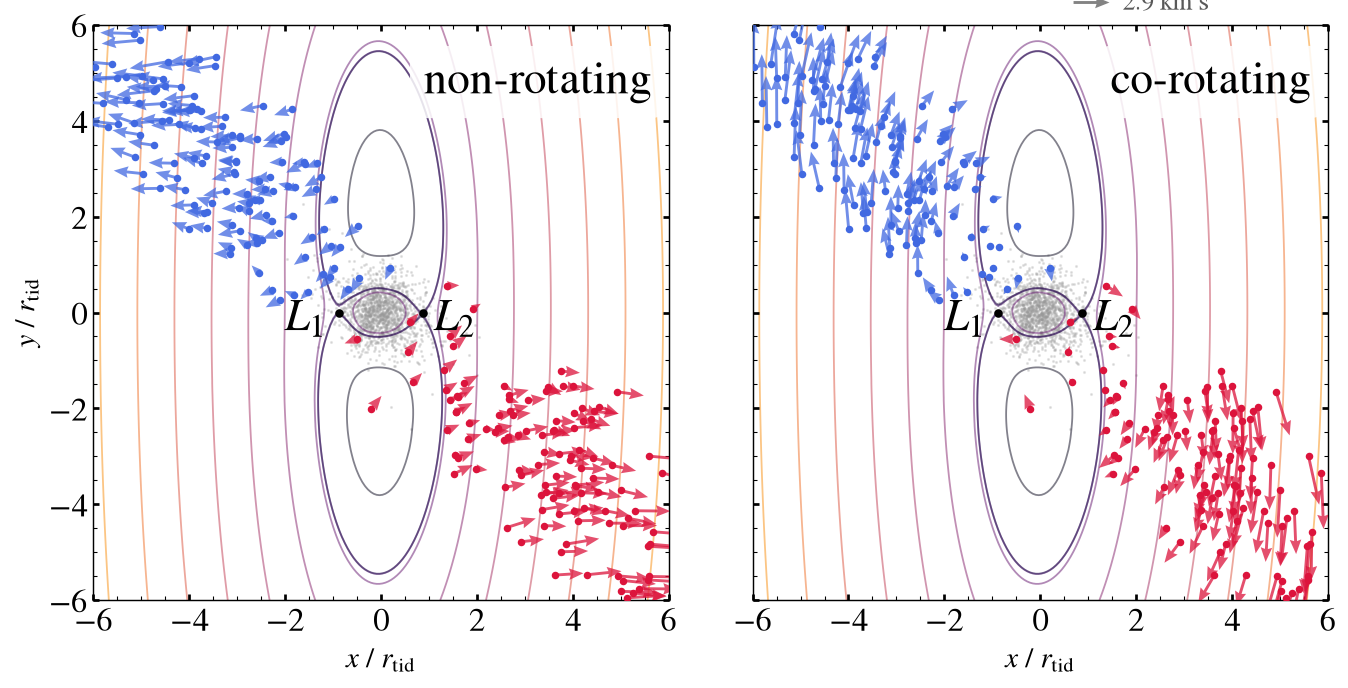

In [43]:
from tambora.dynamics.forces import DirectSummationGravity, ExternalGalpyPotential, FalcONGravity
from tambora.tools.util.units import KMS_TO_KPCGYR, KPCGYR_TO_KMS
from scipy.interpolate import RegularGridInterpolator

t_ind = -10
skip_bnd = 1
skip_unbnd = 2
half, ngrid = 6, 200      # half-width of the frame in tidal radii, grid resolution
eps = 0.015                # the softening the run used
n_arrows = sum(~bnd) // skip_unbnd            # velocity vectors drawn per arm
arrow_len = 0.75             # r_tid drawn for a v95 arrow

t_now = stream.times[t_ind]
bnd = bh.mask_at(t_now)

com, com_vel = np.array(bh.com), np.array(bh.com_vel)
com_t_ind = np.argmin(np.abs(t_now - bh.t))
r_c, v_c = com[com_t_ind], com_vel[com_t_ind]

m_bnd = stream.mass[bnd]
rt = host.rtide(R=np.hypot(r_c[0], r_c[1]) * u.kpc, z=r_c[2] * u.kpc,
                M=np.sum(m_bnd) * u.Msun, quantity=True).to(u.kpc).value

# --- the progenitor's orbital frame -------------------------------------------
# x_hat points radially outward from the Galactic centre, y_hat along the
# direction of motion, and Omega is the orbital angular velocity of the frame.
x_hat = r_c / np.linalg.norm(r_c)
L_hat = np.cross(r_c, v_c); L_hat /= np.linalg.norm(L_hat)
y_hat = np.cross(L_hat, x_hat)
Omega = np.cross(r_c, v_c) / np.dot(r_c, r_c)                 # rad / Gyr

# --- a grid of massless tracers, in the orbital plane -------------------------
g = np.linspace(-half, half, ngrid)                            # r_tid units
GX, GY = np.meshgrid(g, g)
grid = (r_c + rt * (GX.ravel()[:, None] * x_hat + GY.ravel()[:, None] * y_hat))

# Self-gravity: hand the solver the real particles *and* the tracers in one
# array. The tracers carry zero mass, so they source nothing and merely sample
# the field. Use direct summation -- falcON prunes zero-mass bodies from the
# tree and returns nothing useful at them.
pos_now, vel_now = stream.pos(t_ind), stream.vel(t_ind) * KMS_TO_KPCGYR
pos_all = np.vstack([pos_now, grid])
mass_all = np.concatenate([stream.mass, np.full(len(grid), 1e-10)])
phi_self = FalcONGravity(eps=eps).potential(pos_all, mass_all)[len(pos_now):]

# External field on the same tracers, plus the centrifugal term of the rotating
# frame -- together they make the effective (Jacobi) potential.
ext = ExternalGalpyPotential(host)
phi_ext = ext.potential(grid, t_now)
phi_cen = -0.5 * np.sum(np.cross(Omega, grid) ** 2, axis=1)

# The progenitor is on an eccentric orbit, so the frame has to free-fall with it:
# external + centrifugal do not balance at the COM the way they would on a
# circular orbit, and the leftover linear force would swamp the tidal field. The
# frame's own acceleration cancels it, which is this linear counter-term. (The
# Euler term from dOmega/dt is neglected, as usual in the Hill approximation.)
f_res = ext.acc(r_c[None], t_now)[0] - np.cross(Omega, np.cross(Omega, r_c))
phi_corr = (grid - r_c) @ f_res

phi_eff = (phi_self + phi_ext + phi_cen + phi_corr).reshape(GX.shape)   # (kpc/Gyr)^2

# --- L1 / L2: the saddles of Phi_eff along the radial axis --------------------
s = np.linspace(-half, half, 2001)
phi_interp = RegularGridInterpolator((g, g), phi_eff)          # indexed (y, x)
phi_s = phi_interp(np.column_stack([np.zeros_like(s), s]))
iL1 = np.argmax(np.where(s < -0.3, phi_s, -np.inf))
iL2 = np.argmax(np.where(s > 0.3, phi_s, -np.inf))
xL, phi_L = s[[iL1, iL2]], phi_s[[iL1, iL2]]
dphi = phi_eff - phi_L.min()                # measure from the escape threshold

# --- particles in the orbital frame -------------------------------------------
dpos, dvel = pos_now - r_c, vel_now - v_c
X, Y = dpos @ x_hat / rt, dpos @ y_hat / rt
V = {'non-rotating': dvel,                                     # COM frame
     'co-rotating':  dvel - np.cross(Omega, dpos)}             # + frame rotation
V = {k: (w @ x_hat, w @ y_hat) for k, w in V.items()}

# Split the arms the same way as above: leading debris is bound less tightly to
# the Galaxy than the progenitor.
E = 0.5 * np.sum(vel_now ** 2, axis=1) + ext.potential(pos_now, t_now)
E_prog = 0.5 * np.dot(v_c, v_c) + ext.potential(r_c[None], t_now)[0]
in_box = (np.abs(X) < half) & (np.abs(Y) < half)
arms = {'leading':  ~bnd & in_box & (E < E_prog),
        'trailing': ~bnd & in_box & (E >= E_prog)}
colour = {'leading': 'royalblue', 'trailing': 'crimson'}

# one arrow scale for both panels, set by the particles in frame
v95 = np.percentile(np.hypot(*[c[in_box & ~bnd] for c in V['non-rotating']]), 95)
rng = np.random.default_rng(0)
draw = {k: rng.choice(np.flatnonzero(m), min(n_arrows, m.sum()), replace=False)
        for k, m in arms.items()}

# --- plot ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 5.6), dpi=130, sharex=True, sharey=True)

levels = np.unique(np.concatenate([np.percentile(dphi, np.linspace(4, 96, 8)),
                                   phi_L - phi_L.min()]))
for ax, frame in zip(axes, V):
    ax.contour(GX, GY, dphi, levels=levels, linewidths=1., alpha=0.5, zorder=1,
               colors=plt.cm.inferno_r(np.linspace(0.25, 0.95, len(levels))))

    # the progenitor's orbit, with the direction of motion
    #ax.axvline(0, c='0.45', lw=1.0, zorder=7)
    # ax.annotate('', xy=(0, 0.5), xytext=(0, -0.2), zorder=8,
    #             arrowprops=dict(arrowstyle='-|>', color='0.45', lw=1.0))

    ax.scatter(X[bnd][::skip_bnd], Y[bnd][::skip_bnd], s=0.5, alpha=0.25, c='0.6', zorder=0)
    for arm, m in arms.items():
        #ax.scatter(X[m][::skip_unbnd], Y[m][::skip_unbnd], s=40, c=colour[arm], zorder=5)
        i = draw[arm]
        ax.scatter(X[i], Y[i], s=10, c=colour[arm], zorder=5)
        q = ax.quiver(X[i], Y[i], V[frame][0][i], V[frame][1][i],
                      angles='xy', scale_units='xy', scale=v95 / arrow_len,
                      width=0.005, headwidth=4, headlength=5, headaxislength=4.5,
                      color=colour[arm], alpha=0.75, zorder=4)

    ax.scatter(xL, [0, 0], s=14, c='k', zorder=6)
    for x_, lab, ha in zip(xL, ('$L_1$', '$L_2$'), ('left', 'right')):
        ax.annotate(lab, (x_, 0), textcoords='offset points',
                    xytext=(-30 if ha == 'left' else 30, -10), ha=ha, zorder=6, fontsize=25)

    ax.text(0.97, 0.94, frame, transform=ax.transAxes, ha='right', va='top', fontsize=25,
            zorder=9, bbox=dict(boxstyle='round,pad=0.3', fc='w', ec='none', alpha=0.85))
    ax.set_xlim(-half, half); ax.set_ylim(-half, half)
    ax.set_xticks([-6, -4, -2, 0, 2, 4, 6]); ax.set_yticks([-6, -4, -2, 0, 2, 4, 6])
    ax.set_aspect('equal')
    ax.set_xlabel('$x$ / $r_{\\rm tid}$')

axes[0].set_ylabel('$y$ / $r_{\\rm tid}$')
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.11, top=0.90, wspace=0.05)
axes[1].quiverkey(q, 0.62, 1.04, v95, f'{v95 * KPCGYR_TO_KMS:.1f} km s$^{{-1}}$',
                  labelpos='E', coordinates='axes', color='0.35', labelcolor='0.35')
plt.show()


Running the same construction at every snapshot shows the tails being fed through $L_1$ and $L_2$, and the Hill surface breathing as the progenitor moves between pericentre and apocentre. falcON makes the per-frame potential cheap enough to do this for the whole run.

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

# Show every `stride`-th snapshot; raise it to shrink the gif. falcON keeps the
# per-frame gravity cheap, so this runs in ~2 minutes.
stride = 4
frames = np.arange(0, len(stream.times), stride)

# A fixed random subset is eligible for a velocity vector, so the arrows follow
# the *same* stars from frame to frame instead of flickering between samples.
arrow_ids = np.random.default_rng(1).random(len(stream.mass)) < 1 / skip_unbnd

sa = np.linspace(-half, half, 1001)
ext = ExternalGalpyPotential(host)


def hill_frame(i):
    """Effective potential + debris kinematics at snapshot *i*, in the
    progenitor's orbital frame. Same construction as the still figure above."""
    t = stream.times[i]
    bnd = bh.mask_at(t)
    k = np.argmin(np.abs(t - np.array(bh.t)))
    r_c, v_c = np.array(bh.com)[k], np.array(bh.com_vel)[k]

    rt = host.rtide(R=np.hypot(r_c[0], r_c[1]) * u.kpc, z=r_c[2] * u.kpc,
                    M=np.sum(stream.mass[bnd]) * u.Msun, quantity=True).to(u.kpc).value

    x_hat = r_c / np.linalg.norm(r_c)
    L_hat = np.cross(r_c, v_c); L_hat /= np.linalg.norm(L_hat)
    y_hat = np.cross(L_hat, x_hat)
    Omega = np.cross(r_c, v_c) / np.dot(r_c, r_c)

    grid = r_c + rt * (GX.ravel()[:, None] * x_hat + GY.ravel()[:, None] * y_hat)
    pos, vel = stream.pos(i), stream.vel(i) * KMS_TO_KPCGYR
    phi_self = FalcONGravity(eps=eps).potential(
        np.vstack([pos, grid]),
        np.concatenate([stream.mass, np.full(len(grid), 1e-10)]))[len(pos):]
    f_res = ext.acc(r_c[None], t)[0] - np.cross(Omega, np.cross(Omega, r_c))
    phi = (phi_self + ext.potential(grid, t)
           - 0.5 * np.sum(np.cross(Omega, grid) ** 2, axis=1)
           + (grid - r_c) @ f_res).reshape(GX.shape)

    phi_s = RegularGridInterpolator((g, g), phi)(
        np.column_stack([np.zeros_like(sa), sa]))
    iL = [np.argmax(np.where(sa < -0.3, phi_s, -np.inf)),
          np.argmax(np.where(sa > 0.3, phi_s, -np.inf))]
    xL, phi_L = sa[iL], phi_s[iL]

    dpos, dvel = pos - r_c, vel - v_c
    X, Y = dpos @ x_hat / rt, dpos @ y_hat / rt
    vel_frame = {'non-rotating': dvel, 'co-rotating': dvel - np.cross(Omega, dpos)}
    E = 0.5 * np.sum(vel ** 2, axis=1) + ext.potential(pos, t)
    E_prog = 0.5 * np.dot(v_c, v_c) + ext.potential(r_c[None], t)[0]
    in_box = (np.abs(X) < half) & (np.abs(Y) < half)

    return dict(t=t, X=X, Y=Y, bnd=bnd, xL=xL, in_box=in_box,
                dphi=phi - phi_L.min(), dphi_L=phi_L - phi_L.min(),
                V={k: (w @ x_hat, w @ y_hat) for k, w in vel_frame.items()},
                arms={'leading':  ~bnd & in_box & (E < E_prog),
                      'trailing': ~bnd & in_box & (E >= E_prog)})


# One arrow scale for the whole animation, so a given speed always draws the
# same length: the median of the per-frame v95 over a handful of frames.
v95_a = np.median([np.percentile(
    np.hypot(*[c[f['in_box'] & ~f['bnd']] for c in f['V']['non-rotating']]), 95)
    for f in (hill_frame(i) for i in frames[len(frames) // 3::max(len(frames) // 6, 1)])])

fig, axes = plt.subplots(1, 2, figsize=(11, 5.6), dpi=100, sharex=True, sharey=True)
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.11, top=0.90, wspace=0.05)
label_box = dict(boxstyle='round,pad=0.3', fc='w', ec='none', alpha=0.85)


def update(i):
    f = hill_frame(i)
    levels = np.unique(np.concatenate([np.percentile(f['dphi'], np.linspace(4, 96, 8)),
                                       f['dphi_L']]))
    for ax, frame in zip(axes, f['V']):
        ax.clear()
        ax.contour(GX, GY, f['dphi'], levels=levels, linewidths=1., alpha=0.5, zorder=1,
                   colors=plt.cm.inferno_r(np.linspace(0.25, 0.95, len(levels))))

        ax.scatter(f['X'][f['bnd']][::skip_bnd], f['Y'][f['bnd']][::skip_bnd],
                   s=0.5, alpha=0.25, c='0.6', zorder=0)
        for arm, m in f['arms'].items():
            sel = m & arrow_ids
            if not sel.any():
                continue
            ax.scatter(f['X'][sel], f['Y'][sel], s=10, c=colour[arm], zorder=5)
            ax.quiver(f['X'][sel], f['Y'][sel],
                      f['V'][frame][0][sel], f['V'][frame][1][sel],
                      angles='xy', scale_units='xy', scale=v95_a / arrow_len,
                      width=0.0025, headwidth=4, headlength=5, headaxislength=4.5,
                      color=colour[arm], alpha=0.5, zorder=4)

        ax.scatter(f['xL'], [0, 0], s=14, c='k', zorder=6)
        for x_, lab, ha in zip(f['xL'], ('$L_1$', '$L_2$'), ('left', 'right')):
            ax.annotate(lab, (x_, 0), textcoords='offset points',
                        xytext=(-30 if ha == 'left' else 30, -10), ha=ha,
                        zorder=6, fontsize=25)

        ax.text(0.97, 0.94, frame, transform=ax.transAxes, ha='right', va='top',
                fontsize=25, zorder=9, bbox=label_box)
        ax.set_xlim(-half, half); ax.set_ylim(-half, half)
        ax.set_xticks([-6, -4, -2, 0, 2, 4, 6]); ax.set_yticks([-6, -4, -2, 0, 2, 4, 6])
        ax.set_aspect('equal')
        ax.set_xlabel('$x$ / $r_{\\rm tid}$')

    axes[0].set_ylabel('$y$ / $r_{\\rm tid}$')
    axes[0].text(0.03, 0.05, f"$t$ = {f['t']:.2f} Gyr", transform=axes[0].transAxes,
                 va='bottom', fontsize=20, zorder=9, bbox=label_box)


ani = FuncAnimation(fig, update, frames=frames, interval=125)

# Real .gif via Pillow (no ffmpeg); embedded as image/gif in the saved output so
# it ships with nb_execution_mode="off". Re-run locally + commit to refresh.
ani.save('GC_stream_hill.gif', writer=PillowWriter(fps=8))
plt.close(fig)

Image('GC_stream_hill.gif', embed=True)

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.signal import argrelmin

stride = 4
frames = np.arange(0, len(stream.times), stride)
# Same animation as above with two more panels underneath: the whole stream seen
# face-on in the progenitor's orbital plane, and the bound fraction. Everything
# built in the previous cell (hill_frame, frames, v95_a, ...) is reused.

# --- a fixed face-on view of the orbital plane --------------------------------
# Not the corotating frame of the panels above -- the basis is built once from
# the angular momentum of the COM track, so the orbit stays put while the stream
# grows along it.
com_a, com_vel_a = np.array(bh.com), np.array(bh.com_vel)
L_orb = np.cross(com_a, com_vel_a).mean(0); L_orb /= np.linalg.norm(L_orb)
e1 = com_a[0] - L_orb * np.dot(com_a[0], L_orb); e1 /= np.linalg.norm(e1)
e2 = np.cross(L_orb, e1)

to_plane = lambda p: np.column_stack([p @ e1, p @ e2])
com_plane = to_plane(com_a)
orb_lim = 2.25 * np.percentile(np.abs(to_plane(stream.pos(-1))), 99.5)

# Stripping times share one colour scale across the animation, so a colour means
# the same age in every frame.
strip_norm = Normalize(0, stream.times[-1])
strip_cmap = 'inferno_r'

# --- bound fraction, and the pericentres that drive it ------------------------
frac_t, frac = np.array(bh.t), bh.fraction()
peri_t = frac_t[argrelmin(np.linalg.norm(com_a, axis=1))[0]]

# --- figure -------------------------------------------------------------------
fig = plt.figure(figsize=(11, 10.5), dpi=90)
outer = fig.add_gridspec(2, 1, height_ratios=[1, 0.95], hspace=0.22,
                         left=0.08, right=0.97, bottom=0.07, top=0.95)
gs_top = outer[0].subgridspec(1, 2, wspace=0.05)     # the two Hill panels, shared axes
gs_bot = outer[1].subgridspec(1, 2, wspace=0.35)     # room for the colourbar
axes = [fig.add_subplot(gs_top[0])]
axes.append(fig.add_subplot(gs_top[1], sharex=axes[0], sharey=axes[0]))
ax_orb = fig.add_subplot(gs_bot[0])
ax_frac = fig.add_subplot(gs_bot[1])

# one colourbar for the whole animation (the axes get cleared every frame, so it
# has to live outside `update`)
cb = fig.colorbar(ScalarMappable(norm=strip_norm, cmap=strip_cmap), ax=ax_orb, pad=0.02)
cb.set_label('Time Since Stripping [Gyr]')


def update(i):
    f = hill_frame(i)
    t, bnd_i = f['t'], f['bnd']

    # --- the two Hill panels (unchanged) --------------------------------------
    levels = np.unique(np.concatenate([np.percentile(f['dphi'], np.linspace(4, 96, 8)),
                                       f['dphi_L']]))
    for ax, frame in zip(axes, f['V']):
        ax.clear()
        ax.contour(GX, GY, f['dphi'], levels=levels, linewidths=1., alpha=0.5, zorder=1,
                   colors=plt.cm.inferno_r(np.linspace(0.25, 0.95, len(levels))))

        ax.scatter(f['X'][bnd_i][::skip_bnd], f['Y'][bnd_i][::skip_bnd],
                   s=0.5, alpha=0.25, c='0.6', zorder=0)
        for arm, m in f['arms'].items():
            sel = m & arrow_ids
            if not sel.any():
                continue
            ax.scatter(f['X'][sel], f['Y'][sel], s=10, c=colour[arm], zorder=5)
            ax.quiver(f['X'][sel], f['Y'][sel],
                      f['V'][frame][0][sel], f['V'][frame][1][sel],
                      angles='xy', scale_units='xy', scale=v95_a / arrow_len,
                      width=0.0025, headwidth=4, headlength=5, headaxislength=4.5,
                      color=colour[arm], alpha=0.5, zorder=4)

        ax.scatter(f['xL'], [0, 0], s=14, c='k', zorder=6)
        for x_, lab, ha in zip(f['xL'], ('$L_1$', '$L_2$'), ('left', 'right')):
            ax.annotate(lab, (x_, 0), textcoords='offset points',
                        xytext=(-30 if ha == 'left' else 30, -10), ha=ha,
                        zorder=6, fontsize=25)

        ax.text(0.97, 0.94, frame, transform=ax.transAxes, ha='right', va='top',
                fontsize=25, zorder=9, bbox=label_box)
        ax.set_xlim(-half, half); ax.set_ylim(-half, half)
        ax.set_xticks([-6, -4, -2, 0, 2, 4, 6]); ax.set_yticks([-6, -4, -2, 0, 2, 4, 6])
        ax.set_aspect('equal')
        ax.set_xlabel('$x$ / $r_{\\rm tid}$')

    axes[0].set_ylabel('$y$ / $r_{\\rm tid}$')
    axes[0].text(0.03, 0.05, f'$t$ = {t:.2f} Gyr', transform=axes[0].transAxes,
                 va='bottom', fontsize=20, zorder=9, bbox=label_box)

    # --- the stream, face-on in the orbital plane -----------------------------
    ax_orb.clear()
    xy = to_plane(stream.pos(i))
    ax_orb.plot(com_plane[:, 0], com_plane[:, 1], c='k', alpha=0.5, lw=0.5, zorder=0,
                label='bound COM trajectory')
    ax_orb.scatter(xy[~bnd_i, 0], xy[~bnd_i, 1], c='k', s=1, zorder=1)
    ax_orb.scatter(xy[bnd_i, 0][::skip_bnd], xy[bnd_i, 1][::skip_bnd], s=2, c='r',
                   zorder=2, label='bound particles')
    ax_orb.set_xlim(-orb_lim, orb_lim); ax_orb.set_ylim(-orb_lim, orb_lim)
    ax_orb.set_aspect('equal')
    ax_orb.set_xlabel('$x_{\\rm orb}$ [kpc]')
    ax_orb.set_ylabel('$y_{\\rm orb}$ [kpc]')
    ax_orb.legend(loc='upper right', fontsize=10, framealpha=0.85, markerscale=4)

    # --- bound fraction -------------------------------------------------------
    ax_frac.clear()
    for tp in peri_t:
        ax_frac.axvline(tp, c='0.85', lw=0.8, zorder=0)
    ax_frac.plot(frac_t, frac, c='k', lw=1.2, zorder=1)
    ax_frac.axvline(t, c='0.45', lw=1.0, zorder=2)
    ax_frac.scatter([t], [bnd_i.mean()], s=30, c='r', zorder=3)
    ax_frac.set_xlim(frac_t[0], frac_t[-1]); ax_frac.set_ylim(0, 1.02)
    ax_frac.set_xlabel('$t$ [Gyr]')
    ax_frac.set_ylabel('Bound Fraction')


ani = FuncAnimation(fig, update, frames=frames, interval=125)

# Real .gif via Pillow (no ffmpeg); embedded as image/gif in the saved output so
# it ships with nb_execution_mode="off". Re-run locally + commit to refresh.
ani.save('GC_stream_hill_panels.gif', writer=PillowWriter(fps=8))
plt.close(fig)

Image('GC_stream_hill_panels.gif', embed=True)


The boundedness hook records *when* each particle was released, and the machinery above says where the Lagrange points are, so we can ask where along the cluster–Galactic centre line stripping actually happens — the assumption particle-spray codes are built on.

In [ ]:
# --- where along the cluster-Galactic centre line are particles released? -----
# For every particle the hook flagged as unbound, take the snapshot nearest its
# release time and measure the offset from the progenitor in that snapshot's
# orbital frame, in units of that snapshot's tidal radius. hill_frame() already
# builds exactly that frame (and locates L1/L2), so this is a loop over the
# snapshots where releases happened. The snapshot spacing smears the position by
# ~0.1 r_tid; re-running with BoundednessHook(..., capture_transitions=('pos',
# 'vel')) would record the exact phase space coordinates at each flip instead.
t_skip = 0.05          # ignore releases in the first t_skip Gyr (King sphere settling)
lim = 3.               # plot range in r_tid
nbin_2d, nbin_1d = 50, 48

t_last = stream.times[-1]
t_rel = bh.release_time(t_last)                  # nan if still bound at the end
ok = np.isfinite(t_rel) & (t_rel > t_skip)
idx = np.flatnonzero(ok)
snap_of = np.argmin(np.abs(stream.times[None, :] - t_rel[ok][:, None]), axis=1)

# Which arm each particle ends up in, decided at the *final* snapshot by the
# usual energy criterion -- independent of where it was released.
k_end = np.argmin(np.abs(t_last - np.array(bh.t)))
r_c_e, v_c_e = np.array(bh.com)[k_end], np.array(bh.com_vel)[k_end]
lead_end = (0.5 * np.sum((stream.vel(-1) * KMS_TO_KPCGYR) ** 2, axis=1)
            + ext.potential(stream.pos(-1), t_last)
            < 0.5 * np.dot(v_c_e, v_c_e) + ext.potential(r_c_e[None], t_last)[0])

xr, yr, zr, xL_all = [], [], [], []
for j in np.unique(snap_of):
    sel = idx[snap_of == j]
    f = hill_frame(j)
    # hill_frame returns the in-plane offsets; the out-of-plane one is needed for
    # the isotropic null below, so rebuild the frame's normal here.
    k = np.argmin(np.abs(f['t'] - np.array(bh.t)))
    r_c, v_c = np.array(bh.com)[k], np.array(bh.com_vel)[k]
    L_hat = np.cross(r_c, v_c); L_hat /= np.linalg.norm(L_hat)
    rt_j = host.rtide(R=np.hypot(r_c[0], r_c[1]) * u.kpc, z=r_c[2] * u.kpc,
                      M=np.sum(stream.mass[f['bnd']]) * u.Msun,
                      quantity=True).to(u.kpc).value
    xr.append(f['X'][sel]); yr.append(f['Y'][sel])
    zr.append((stream.pos(j)[sel] - r_c) @ L_hat / rt_j)
    xL_all.append(f['xL'])
xr, yr, zr = np.concatenate(xr), np.concatenate(yr), np.concatenate(zr)
xL_med = np.median(np.array(xL_all), axis=0)
lead_r = lead_end[idx]

# Null hypothesis: same release *radii*, but isotropic directions. Projecting an
# isotropic 3D offset onto x gives x = r * U(-1, 1), so a release that ignored
# the Lagrange points would fill in the centre instead of peaking at +/- r_tid.
r3 = np.sqrt(xr ** 2 + yr ** 2 + zr ** 2)
x_iso = r3 * np.random.default_rng(0).uniform(-1, 1, size=(20, r3.size))

# the Hill surface of a representative snapshot, as a visual guide
j_rep = np.unique(snap_of)[len(np.unique(snap_of)) // 2]
f_rep = hill_frame(j_rep)

# --- plot ---------------------------------------------------------------------
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12.5, 5.4), dpi=110)

ax0.hist2d(xr, yr, bins=nbin_2d, range=[[-lim, lim], [-lim, lim]],
           cmap='inferno_r', cmin=1)
ax0.contour(GX, GY, f_rep['dphi'], levels=[0], colors='k', linewidths=1.,
            linestyles='--', alpha=0.6)
ax0.scatter(f_rep['xL'], [0, 0], s=25, c='k', zorder=5)
for x_, lab in zip(f_rep['xL'], ('$L_1$', '$L_2$')):
    ax0.annotate(lab, (x_, 0), textcoords='offset points', xytext=(0, 10),
                 ha='center', zorder=5, fontsize=16)
ax0.set_xlim(-lim, lim); ax0.set_ylim(-lim, lim)
ax0.set_aspect('equal')
ax0.set_xlabel('$x$ / $r_{\\rm tid}$ at release')
ax0.set_ylabel('$y$ / $r_{\\rm tid}$ at release')

bins = np.linspace(-lim, lim, nbin_1d + 1)
ax1.hist(xr, bins=bins, color='0.8', label=f'all releases ({len(xr)})')
for lab, m, c in (('leading', lead_r, 'royalblue'), ('trailing', ~lead_r, 'crimson')):
    ax1.hist(xr[m], bins=bins, histtype='step', lw=1.5, color=c, label=lab)
ax1.stairs(np.histogram(x_iso, bins=bins)[0] / len(x_iso), bins, color='k',
           ls='--', lw=1.5, label='isotropic, same radii')
for x_, lab in zip(xL_med, ('$L_1$', '$L_2$')):
    ax1.axvline(x_, c='k', lw=1., alpha=0.6)
    ax1.annotate(lab, (x_, 1), xycoords=('data', 'axes fraction'),
                 textcoords='offset points', xytext=(0, -20), ha='center', fontsize=16)
ax1.set_xlim(-lim, lim)
ax1.set_xlabel('$x$ / $r_{\\rm tid}$ at release')
ax1.set_ylabel('N released')
ax1.legend(fontsize=11, loc='lower center', framealpha=0.9, edgecolor='none')
fig.tight_layout()
plt.show()

inner, outer = xr < 0, xr > 0
print(f'{ok.sum()} releases used ({np.isfinite(t_rel).sum()} total, '
      f'{(np.isfinite(t_rel) & ~ok).sum()} before t = {t_skip} Gyr dropped)')
print(f'Lagrange points (median over the run):  L1 = {xL_med[0]:+.2f}, '
      f'L2 = {xL_med[1]:+.2f} r_tid')
print(f'release offset   inner side: {np.mean(xr[inner]):+.2f} +/- {np.std(xr[inner]):.2f} r_tid'
      f'  ({inner.sum()} particles)')
print(f'release offset   outer side: {np.mean(xr[outer]):+.2f} +/- {np.std(xr[outer]):.2f} r_tid'
      f'  ({outer.sum()} particles)')
print(f'|y| < |x| at release: {np.mean(np.abs(yr) < np.abs(xr)):.0%} (50% if isotropic)')
print(f'leading arm released on the inner side: {np.mean(xr[lead_r] < 0):.0%};  '
      f'trailing on the outer side: {np.mean(xr[~lead_r] > 0):.0%}')


Since we have the boundedness hook, we have access to the precise path of the satellite's bound center of mass and the times that particles became unbound. We can see that, as expected, particles are stripped in a skew-symmetric distribution around pericenter.

In [45]:
from scipy.signal import argrelmin

# find time of prog. pericenters
prog_com_r = np.linalg.norm(np.array(bh.com), axis=-1)
peri_inds = argrelmin(prog_com_r)[0]
peri_ts = [bh.t[peri_ind] for peri_ind in peri_inds]

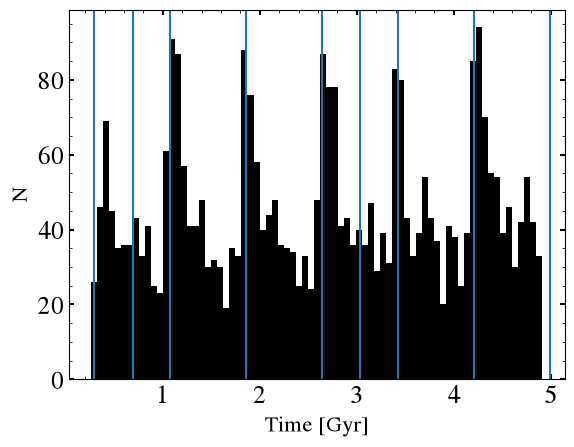

In [46]:
mask = bh.mask_at(stream.times[t_ind])
t_rls =  bh.release_time(stream.times[t_ind])[~mask]
t_since_rls = stream.times[t_ind] - t_rls
plt.hist(t_rls, color='k', bins=75)
[plt.axvline(peri_t) for peri_t in peri_ts]
plt.xlabel('Time [Gyr]')
plt.ylabel('N') 
plt.show()

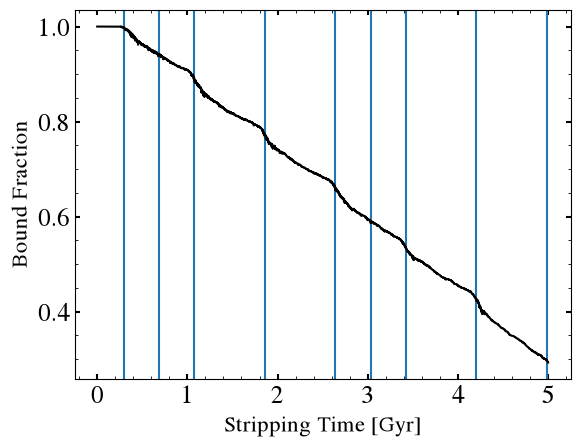

In [47]:
[plt.axvline(peri_t) for peri_t in peri_ts]
plt.plot(bh.t, bh.fraction(), c='k')
plt.xlabel('Stripping Time [Gyr]')
plt.ylabel('Bound Fraction')
plt.show()

## Analysing the Stream with `galpy`

In [78]:
from galpy.orbit import Orbit
from galpy.util import coords, conversion
from tambora.tools.util.units import KPCGYR_TO_KMS

ro, vo, zo = 8., 220., 0.0208          # zo = galpy's default solar height

bnd = bh.mask_at(stream.times[t_ind])

# --- the progenitor's orbit, from the bound remnant's *present* phase space ---
# bh.com/bh.com_vel are in INTERNAL units (kpc, kpc/Gyr), so the velocity needs
# converting to km/s before galpy sees it.
com, com_vel = np.array(bh.com), np.array(bh.com_vel)
com
c_now, v_now = com[com_t_ind], com_vel[com_t_ind] * KPCGYR_TO_KMS

R, phi, z = coords.rect_to_cyl(*c_now)
vR, vT, vz = coords.rect_to_cyl_vec(*v_now, *c_now, cyl=False)
prog = Orbit([R*u.kpc, vR*u.km/u.s, vT*u.km/u.s, z*u.kpc, vz*u.km/u.s, phi*u.rad],
             ro=ro, vo=vo)

# The 3x3 rotation from (ra, dec) into the stream frame. phi1 runs along the
# progenitor's orbit, phi2 perpendicular to it; the progenitor sits at phi1=180
# by default, which keeps us away from the 0/360 wrap.
rot = prog.align_to_orbit()

print(f"progenitor: R = {R:.2f} kpc, {prog.dist(quantity=False):.1f} kpc from the Sun")
print(f"in its own frame: phi1 = {prog.phi1(quantity=False):.1f} deg, "
      f"phi2 = {prog.phi2(quantity=False):.2f} deg")

progenitor: R = 12.75 kpc, 7.5 kpc from the Sun
in its own frame: phi1 = 180.0 deg, phi2 = 0.00 deg


In [79]:
from galpy.potential import evaluatePotentials

# --- the spine the debris gets projected onto -------------------------------
# from_particles needs the progenitor orbit sampled on BOTH sides of tp=0: the
# leading arm lives at tp>0 and the trailing arm at tp<0, so integrate the
# progenitor forwards and backwards and stitch the two halves together.
#
# T_span must be long enough for the spine to reach the far end of the debris --
# if the fitted track stops short of the tails, lengthen it.
T_span, n = 0.7, 400                                  # Gyr each way
tf, tb = np.linspace(0, T_span, n)*u.Gyr, np.linspace(0, -T_span, n)*u.Gyr
o_fwd, o_bwd = prog(), prog()
o_fwd.integrate(tf, host)
o_bwd.integrate(tb, host)

def _cart(o, ts):
    return np.array([o.x(ts, quantity=False), o.y(ts, quantity=False), o.z(ts, quantity=False),
                     o.vx(ts, quantity=False), o.vy(ts, quantity=False), o.vz(ts, quantity=False)]).T

prog_cart = np.vstack([_cart(o_bwd, tb)[::-1][:-1], _cart(o_fwd, tf)])   # (M, 6), monotonic in tp
t_gyr = np.concatenate([np.linspace(-T_span, 0, n)[:-1], np.linspace(0, T_span, n)])

# from_particles wants galpy INTERNAL units
prog_cart_int = prog_cart / np.array([ro, ro, ro, vo, vo, vo])
t_int = t_gyr / conversion.time_in_Gyr(vo, ro)

# --- debris -> galpy's (R, vR, vT, z, vz, phi) ------------------------------
p, v = stream.stars.pos(t_ind)[~bnd], stream.stars.vel(t_ind)[~bnd]
Rd, phid, zd = coords.rect_to_cyl(p[:, 0], p[:, 1], p[:, 2])
vRd, vTd, vzd = coords.rect_to_cyl_vec(v[:, 0], v[:, 1], v[:, 2],
                                       p[:, 0], p[:, 1], p[:, 2], cyl=False)
xv = np.array([Rd/ro, vRd/vo, vTd/vo, zd/ro, vzd/vo, phid])      # (6, N), internal

# --- split the arms: leading debris sits at lower energy than the progenitor -
_pot = lambda R_, z_: evaluatePotentials(host, R_*u.kpc, z_*u.kpc,
                                         quantity=True).to(u.km**2/u.s**2).value
E_debris = 0.5*(vRd**2 + vTd**2 + vzd**2) + _pot(Rd, zd)
E_prog = 0.5*np.sum(v_now**2) + _pot(R, z)
lead = E_debris < E_prog

print(f"spine: {prog_cart_int.shape[0]} points, tp in [{t_int.min():.1f}, {t_int.max():.1f}]")
print(f"leading: {lead.sum()}   trailing: {(~lead).sum()}")

spine: 799 points, tp in [-19.7, 19.7]
leading: 779   trailing: 840


In [80]:
from galpy.df import StreamTrack

# One track per arm. Passing custom_sky_transform lets the track report itself in
# (phi1, phi2) directly. solarmotion must be a 3-vector here (the string aliases
# Orbit accepts are not supported).
tracks = {
    name: StreamTrack.from_particles(
        xv[:, sel], track_prog_cart=prog_cart_int, track_t_grid=t_int,
        arm_sign=sign, custom_sky_transform=rot,
        ro=ro, vo=vo, zo=zo, solarmotion=[-11.1, 12.24, 7.25])
    for name, sel, sign in (('leading', lead, +1), ('trailing', ~lead, -1))
}

def to_phi12(xyz):
    """Galactocentric cartesian [kpc] -> stream-frame (phi1, phi2) [deg].

    This is the vectorised version of Orbit.phi1/phi2 (agrees to ~1e-5 deg), so
    it is cheap enough to run on every particle at every snapshot.
    """
    X, Y, Z = coords.galcenrect_to_XYZ(xyz[..., 0], xyz[..., 1], xyz[..., 2],
                                       Xsun=ro, Zsun=zo).T
    l, b, _ = coords.XYZ_to_lbd(X, Y, Z, degree=True).T
    ra, dec = coords.lb_to_radec(l, b, degree=True).T
    return coords.radec_to_custom(ra, dec, T=rot, degree=True).T

phi1, phi2 = to_phi12(p)
print(f"debris phi1: {phi1.min():.0f} .. {phi1.max():.0f} deg"
      f"   phi2: {phi2.min():.1f} .. {phi2.max():.1f} deg")

debris phi1: 99 .. 262 deg   phi2: -6.0 .. 0.9 deg


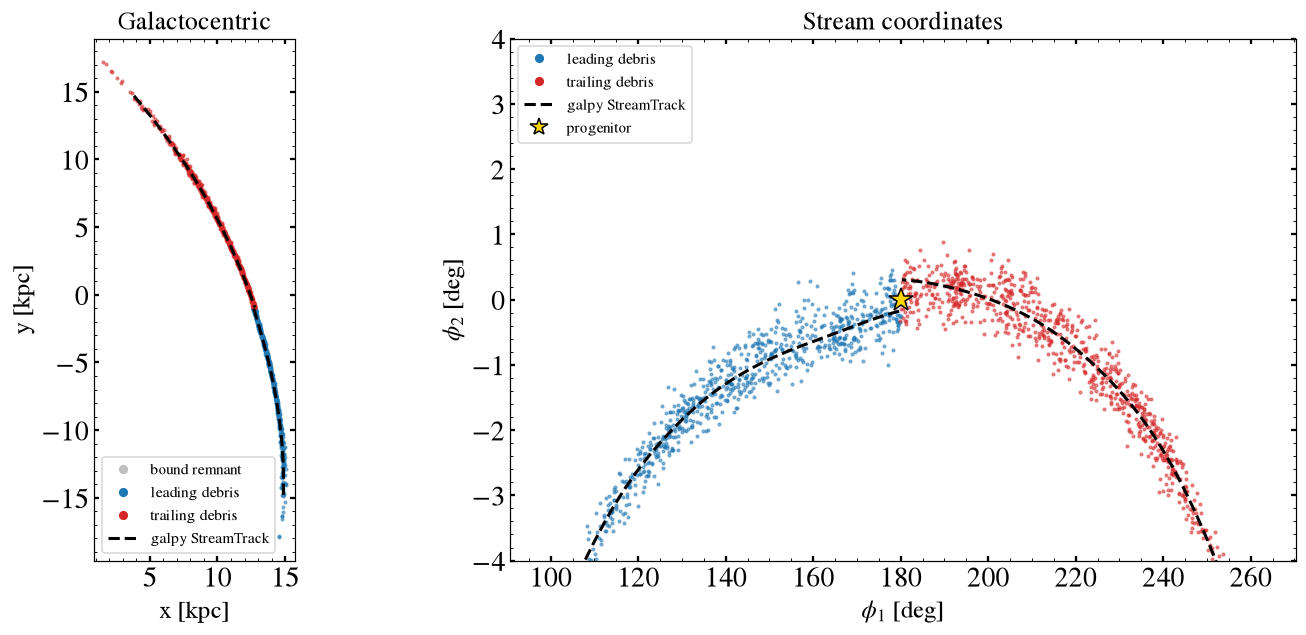

In [81]:
from matplotlib.lines import Line2D

def supported(tr, sel, rmax=1.0):
    """The stretch of track that actually has particles near it.

    from_particles will happily spline across a gap in tp where no debris lives
    (galpy warns when it spots one), which shows up as a straight chord through
    empty space. So keep only tp whose track point is within `rmax` kpc of some
    particle, then take the contiguous run through the progenitor at tp=0.
    """
    tp = tr.tp_grid()
    txyz = np.array([tr.x(tp, quantity=False), tr.y(tp, quantity=False),
                     tr.z(tp, quantity=False)]).T
    ok = np.sqrt(((txyz[:, None, :] - p[sel][None, :, :])**2).sum(-1)).min(1) < rmax
    i0 = np.argmin(np.abs(tp))
    if not ok[i0]:
        return tp[ok]
    lo = hi = i0
    while lo > 0 and ok[lo-1]:
        lo -= 1
    while hi < len(tp)-1 and ok[hi+1]:
        hi += 1
    return tp[lo:hi+1]

colour = {'leading': 'tab:blue', 'trailing': 'tab:red'}
fig, ax = plt.subplots(1, 2, figsize=(14, 6), dpi=110)

ax[0].scatter(stream.stars.pos(t_ind)[bnd, 0], stream.stars.pos(t_ind)[bnd, 1],
              s=1, c='0.75')
for name, sel in (('leading', lead), ('trailing', ~lead)):
    tp = supported(tracks[name], sel)
    ax[0].scatter(p[sel, 0], p[sel, 1], s=3, c=colour[name], alpha=.5)
    ax[0].plot(tracks[name].x(tp, quantity=False), tracks[name].y(tp, quantity=False),
               'k--', lw=2, zorder=5)
    ax[1].scatter(phi1[sel], phi2[sel], s=3, c=colour[name], alpha=.5)
    ax[1].plot(tracks[name].phi1(tp, quantity=False), tracks[name].phi2(tp, quantity=False),
               'k--', lw=2, zorder=5)

ax[1].plot(prog.phi1(quantity=False), prog.phi2(quantity=False), '*',
           ms=16, c='gold', mec='k', zorder=6)

handles = [Line2D([], [], ls='', marker='o', ms=5, c='0.75', label='bound remnant'),
           Line2D([], [], ls='', marker='o', ms=5, c='tab:blue', label='leading debris'),
           Line2D([], [], ls='', marker='o', ms=5, c='tab:red', label='trailing debris'),
           Line2D([], [], ls='--', lw=2, c='k', label='galpy StreamTrack')]
ax[0].legend(handles=handles, fontsize=10)
ax[0].set(xlabel='x [kpc]', ylabel='y [kpc]', title='Galactocentric')
ax[0].set_aspect('equal')

ax[1].legend(handles=handles[1:] + [Line2D([], [], ls='', marker='*', ms=12, c='gold',
                                           mec='k', label='progenitor')],
             fontsize=10, loc='upper left')
ax[1].set(xlabel=r'$\phi_1$ [deg]', ylabel=r'$\phi_2$ [deg]',
          title='Stream coordinates', ylim=(-4, 4))
plt.tight_layout()
plt.show()

We can explore the stream in action-angle coordinates using galpy's convenient tools for action, angle, and frequency calculation.

In [82]:
o_unbnd = Orbit(xv.T)
o_unbnd.turn_physical_on(ro=ro, vo=vo)

In [91]:
from galpy.actionAngle import actionAngleStaeckel
aAI = actionAngleStaeckel(pot=host, c=True, fixed_quad=True, delta=0.25)
aAI.turn_physical_on()

(jr, jp, jz, 
Or, Op, Oz, 
tr, tp, tz) = aAI.actionsFreqsAngles(o_unbnd)

(progjr, progjp, progjz, 
 progOr, progOp, progOz, 
 progtr, progtp, progtz) = aAI.actionsFreqsAngles(prog)

In [92]:
tr = (tr.value + np.pi)%(2*np.pi)
tp = (tp.value + np.pi)%(2*np.pi)
tz = (tz.value + np.pi)%(2*np.pi)

progtr = (progtr.value + np.pi)%(2*np.pi)
progtp = (progtp.value + np.pi)%(2*np.pi)
progtz = (progtz.value + np.pi)%(2*np.pi)

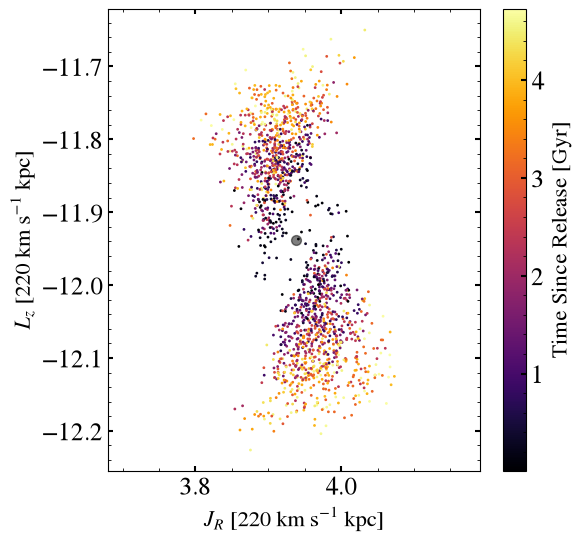

In [93]:
plt.figure(figsize=(6,6))
p = plt.scatter(jr/220, jp/220, s=1, c=t_since_rls, cmap='inferno')
plt.colorbar(p, label='Time Since Release [Gyr]')
plt.scatter(progjr/220, progjp/220, s=50, c='k', alpha=0.5)
plt.axis('equal')
plt.xlabel('$J_R$ [220 km s$^{-1}$ kpc]')
plt.ylabel('$L_z$ [220 km s$^{-1}$ kpc]')
plt.show()

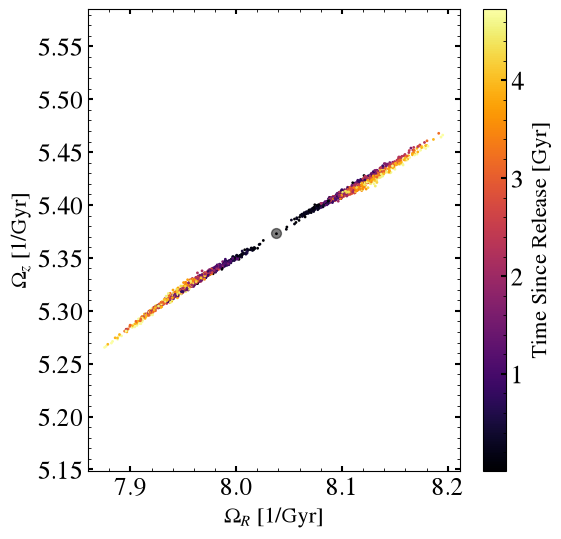

In [94]:
plt.figure(figsize=(6,6))
p = plt.scatter(Or, Oz, s=1., c=t_since_rls, cmap='inferno')
plt.colorbar(p, label='Time Since Release [Gyr]')
plt.scatter(progOr, progOz, s=50, c='k', alpha=0.5)
plt.xlabel('$\\Omega_R$ [1/Gyr]')
plt.ylabel('$\\Omega_z$ [1/Gyr]')
plt.axis('equal')
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\p'

<>:6: SyntaxWarning: invalid escape sequence '\p'

/tmp/ipykernel_1509963/811081197.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\\Omega_{\phi}$ [1/Gyr]')



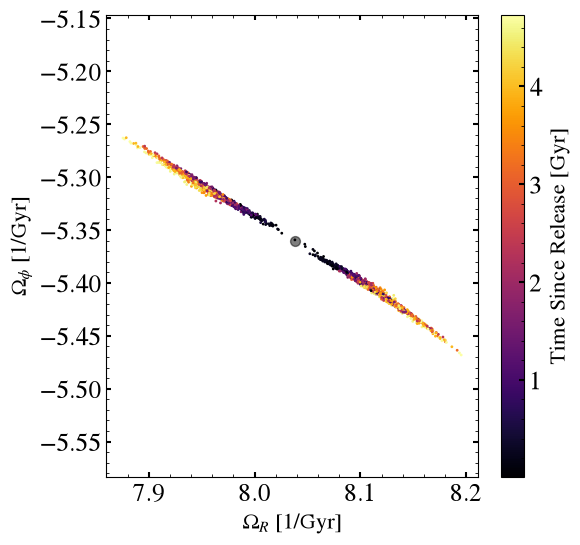

In [95]:
plt.figure(figsize=(6,6))
p = plt.scatter(Or, Op, s=1., c=t_since_rls, cmap='inferno')
plt.colorbar(p, label='Time Since Release [Gyr]')
plt.scatter(progOr, progOp, s=50, c='k', alpha=0.5)
plt.xlabel('$\\Omega_R$ [1/Gyr]')
plt.ylabel('$\\Omega_{\phi}$ [1/Gyr]')
plt.axis('equal')
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\p'

<>:6: SyntaxWarning: invalid escape sequence '\p'

/tmp/ipykernel_1509963/1392109754.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\\theta_{\phi}$')



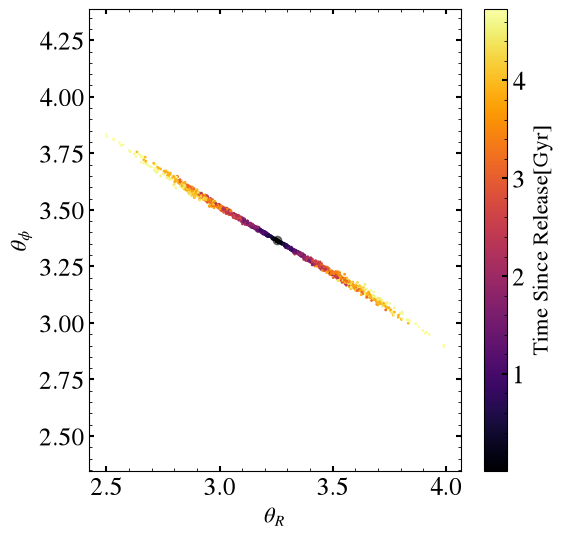

In [96]:
plt.figure(figsize=(6,6))
p = plt.scatter(tr, tp, s=1., c=t_since_rls, cmap='inferno')
plt.colorbar(p, label='Time Since Release[Gyr]')
plt.scatter(progtr, progtp, c='k', alpha=0.5)
plt.xlabel('$\\theta_R$')
plt.ylabel('$\\theta_{\phi}$')
plt.axis('equal')
plt.show()

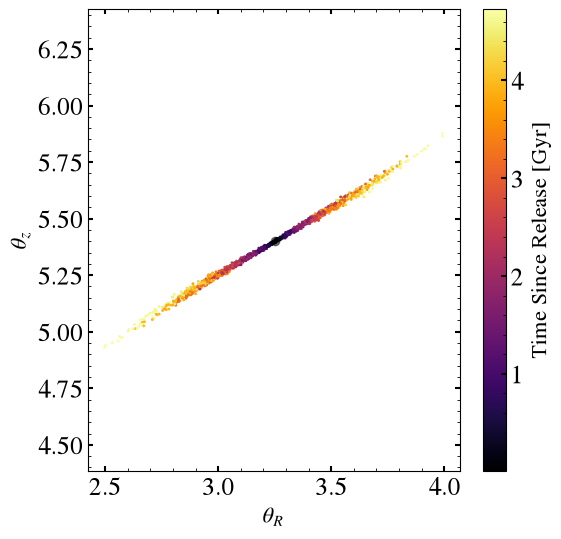

In [97]:
plt.figure(figsize=(6,6))
p = plt.scatter(tr, tz, s=1., c=t_since_rls, cmap='inferno')#
plt.colorbar(p, label='Time Since Release [Gyr]')
plt.scatter(progtr, progtz, c='k', alpha=0.5)
plt.xlabel('$\\theta_R$')
plt.ylabel('$\\theta_z$')
plt.axis('equal')
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\l'

<>:12: SyntaxWarning: invalid escape sequence '\l'

/tmp/ipykernel_1509963/2724777355.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$ \left| \\Delta \\Omega_{\\parallel} \\right|$')



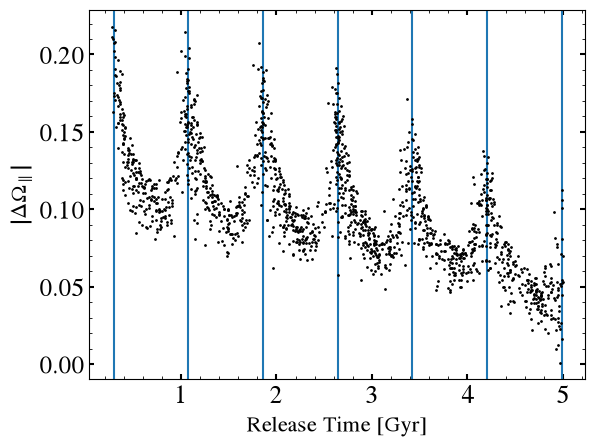

In [100]:
O_vec = np.array([Or, Op, Oz]).T
O_ref = np.array([progOr, progOp, progOz]).T

_, _, Vt = np.linalg.svd(O_vec - O_ref, full_matrices=False)
d_hat = Vt[0]

dO = np.abs(np.dot(O_vec - O_ref, d_hat))

[plt.axvline(peri_t) for peri_t in peri_ts]
plt.scatter(t_rls, dO, s=1, c='k', zorder=100)
plt.xlabel('Release Time [Gyr]')
plt.ylabel('$ \left| \\Delta \\Omega_{\\parallel} \\right|$')
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\l'

<>:12: SyntaxWarning: invalid escape sequence '\l'

/tmp/ipykernel_1509963/3953440315.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$ \left| \\Delta \\theta_{\\parallel} \\right|$')



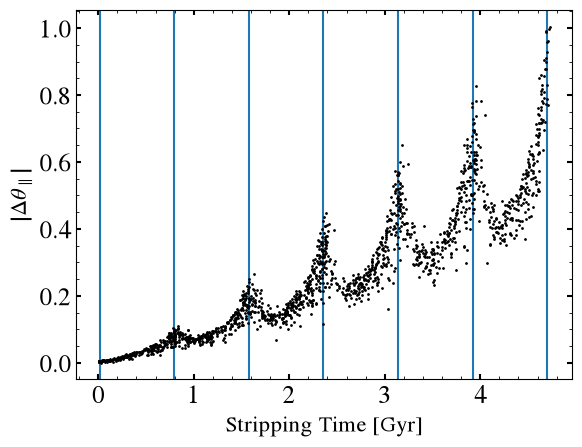

In [103]:
t_vec = np.array([tr, tp, tz]).T
t_ref = np.array([progtr, progtp, progtz]).T

_, _, Vt = np.linalg.svd(t_vec - t_ref, full_matrices=False)
d_hat = Vt[0] 

dth = np.abs(np.dot(t_vec - t_ref, d_hat))

[plt.axvline(stream.times[t_ind] - peri_t) for peri_t in peri_ts]
plt.scatter(t_since_rls, dth, s=1, c='k', zorder=100)
plt.xlabel('Stripping Time [Gyr]')
plt.ylabel('$ \left| \\Delta \\theta_{\\parallel} \\right|$')
plt.show()

## Checking Performance

We can check how well energy is conserved in a few different ways. We can check using the values calculated during integration (fastest):

/geir_data/scr/gabrielspace/tambora/tambora/simulation/simulation.py:1289: UserWarning: Computing external potential on-the-fly for multiple snapshots may be slow.
  warnings.warn("Computing external potential on-the-fly for multiple snapshots may be slow.")



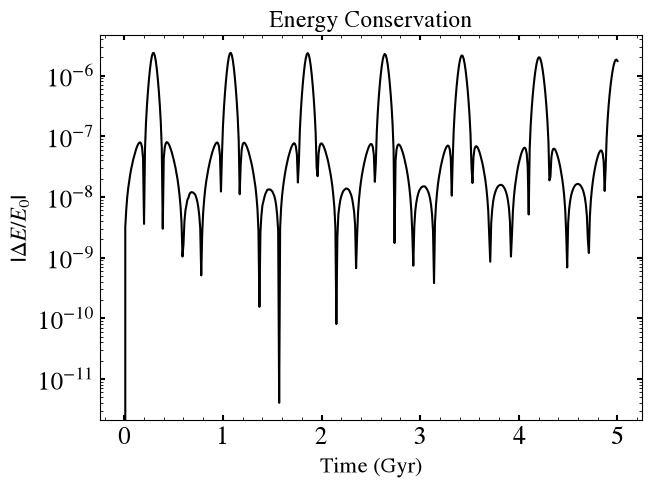

In [ ]:
stream.plot_energy_diagnostic()

We can also check conservation of energy with a different method for calculating the self-gravity potential that is more precise (direct summation, slower). This allows us to ensure 

/geir_data/scr/gabrielspace/tambora/tambora/simulation/simulation.py:1880: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')



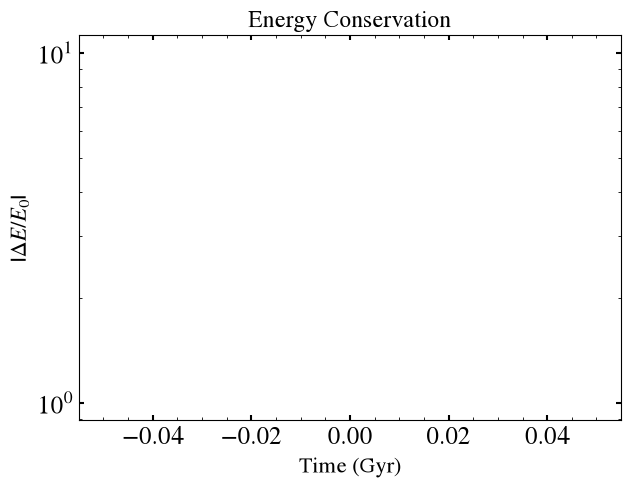

In [ ]:
# direct summation is expensive, so only 
# calculate at 5 snapshots. Runs in ~5.5 minutes

stream.plot_energy_diagnostic(method='direct_C', eps=0.01, nsnap=5)